# WESAD Stress Detection — Improved SSL with BYOL + Temporal Neighbours

**Improvements over SimCLR baseline:**

| Aspect | SimCLR baseline | This notebook |
|--------|-----------------|---------------|
| Algorithm | NT-Xent (needs large negatives) | **BYOL** (no negatives, EMA target) |
| Positive pairs | Two augmented copies of same window | **Temporally adjacent windows** same subject |
| Augmentation | 4 functions, 1 applied per view | **6 functions, 2 composed per view** |
| EMA schedule | Fixed τ | **Cosine τ schedule 0.990 → 0.999** |
| Pretraining data | Train subjects only | **All 15 subjects** (unlabelled) |
| Encoder | 3-layer CNN, 128-dim | **4-layer residual CNN, 256-dim** |
| Ablations | None | **Temporal-K + Augmentation strategy** |

## Before you run

1. Mount Google Drive and set `DATA_ROOT` (cell 4).
2. `scipy` is used for Gaussian smoothing — already in pip check.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted.")
except Exception:
    print("Not in Colab — skipping mount.")

Mounted at /content/drive
Drive mounted.


In [2]:
# import sys, subprocess, importlib

# def pip_install(pkg):
#     try:
#         subprocess.check_call(
#             [sys.executable, "-m", "pip", "install", "-q", pkg],
#             stdout=subprocess.DEVNULL,
#             stderr=subprocess.DEVNULL
#         )
#         return True
#     except Exception as e:
#         print(f"[WARNING] Failed to install {pkg}: {e}")
#         return False

# packages = [
#     ("numpy", "numpy"),
#     ("scipy", "scipy"),
#     ("pandas", "pandas"),
#     ("scikit-learn", "sklearn"),
#     ("matplotlib", "matplotlib"),
#     ("seaborn", "seaborn"),
#     ("tqdm", "tqdm")
# ]

# for pkg, name in packages:
#     try:
#         importlib.import_module(name)
#         print(f"[OK] {name} already installed")
#     except ImportError:
#         print(f"[INFO] Installing {pkg}...")
#         success = pip_install(pkg)
#         if success:
#             try:
#                 importlib.import_module(name)
#                 print(f"[OK] {name} installed successfully")
#             except ImportError:
#                 print(f"[ERROR] {name} still cannot be imported")
#         else:
#             print(f"[SKIPPED] {pkg} installation failed")

# print("Dependency check complete.")

[OK] numpy already installed
[OK] scipy already installed
[OK] pandas already installed
[OK] sklearn already installed
[OK] matplotlib already installed
[OK] seaborn already installed
[OK] tqdm already installed
Dependency check complete.


In [3]:
import sys, subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg, name in [("numpy","numpy"),("scipy","scipy"),("pandas","pandas"),
                   ("scikit-learn","sklearn"),("matplotlib","matplotlib"),
                   ("seaborn","seaborn"),("tqdm","tqdm")]:
    try: __import__(name)
    except Exception: pip_install(pkg)

print("Dependencies ready.")

Dependencies ready.


In [4]:
import os, glob, pickle, random, math, copy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)

# ── Change this ───────────────────────────────────────────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/FIU/class_elements/CAP6619/Project/WESAD"
OUTPUT_DIR = "/content/wesad_byol_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42

ORIG_FS    = 700
DOWNSAMPLE = 10
FS         = ORIG_FS // DOWNSAMPLE   # 70 Hz

WINDOW_SEC = 30
STEP_SEC   = 15
WIN        = WINDOW_SEC * FS
STEP       = STEP_SEC   * FS
PURITY     = 0.90

LABEL_MAP   = {1: 0, 2: 1, 3: 2}
ID2LABEL    = {0: "baseline", 1: "stress", 2: "amusement"}
NUM_CLASSES = 3

# ── Hyper-parameters ─────────────────────────────────────────────────────────
EMB_DIM    = 256
PROJ_DIM   = 256
PRED_DIM   = 128
SSL_BATCH  = 64           # BYOL works fine with small batches
SUP_BATCH  = 128
SSL_EPOCHS = 100
LINEAR_EPOCHS = 30
SUP_EPOCHS    = 30
LR_SSL     = 3e-4
LR_LINEAR  = 1e-3
LR_SUP     = 1e-3
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 10
MIN_LR_FACTOR = 1e-2
EMA_START  = 0.990        # tau at epoch 0
EMA_END    = 0.999        # tau at final epoch (cosine schedule)
TEMPORAL_K = 8            # default positive-pair temporal distance

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(SEED)

Device: cuda


## Data loading (identical pipeline to SimCLR baseline)

In [5]:
def get_key(d, keys):
    for k in keys:
        if k in d: return d[k]
    raise KeyError(f"None of {keys} found")


def load_subject_pkl(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    chest = data["signal"]["chest"]
    y     = np.asarray(data["label"]).reshape(-1)
    acc   = np.asarray(get_key(chest, ["ACC"])).astype(np.float32)
    ecg   = np.asarray(get_key(chest, ["ECG"])).reshape(-1,1).astype(np.float32)
    eda   = np.asarray(get_key(chest, ["EDA"])).reshape(-1,1).astype(np.float32)
    emg   = np.asarray(get_key(chest, ["EMG"])).reshape(-1,1).astype(np.float32)
    resp  = np.asarray(get_key(chest, ["Resp","RESP"])).reshape(-1,1).astype(np.float32)
    temp  = np.asarray(get_key(chest, ["Temp","TEMP"])).reshape(-1,1).astype(np.float32)
    return np.concatenate([acc, ecg, eda, emg, resp, temp], axis=1), y


def make_windows(x, y, win, step, label_map, purity=0.90):
    Xw, yw = [], []
    for s in range(0, len(y) - win + 1, step):
        e = s + win
        seg = y[s:e]
        vals, cnts = np.unique(seg, return_counts=True)
        maj = vals[np.argmax(cnts)]
        if maj not in label_map or cnts.max()/len(seg) < purity: continue
        Xw.append(x[s:e]); yw.append(label_map[maj])
    if not Xw:
        return np.empty((0,win,x.shape[1]),np.float32), np.empty((0,),np.int64)
    return np.stack(Xw).astype(np.float32), np.array(yw,np.int64)


pkl_files = sorted(glob.glob(os.path.join(DATA_ROOT, "S*", "S*.pkl")))
print(f"Found {len(pkl_files)} subject files.")
if not pkl_files:
    raise FileNotFoundError(f"No pkl files under {DATA_ROOT}/S*/S*.pkl")

Found 15 subject files.


In [6]:
X_all_list, y_all_list, groups_all = [], [], []
for pkl_path in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_path))
    x, y = load_subject_pkl(pkl_path)
    x, y = x[::DOWNSAMPLE], y[::DOWNSAMPLE]
    Xw, yw = make_windows(x, y, WIN, STEP, LABEL_MAP, PURITY)
    if not len(Xw): print(f"  {sid}: skipped"); continue
    X_all_list.append(Xw); y_all_list.append(yw)
    groups_all.extend([sid]*len(yw))
    print(f"  {sid}: {len(yw)} windows")

X_all      = np.concatenate(X_all_list)
y_all      = np.concatenate(y_all_list)
groups_all = np.array(groups_all)
N_CH       = X_all.shape[2]
print(f"\nAll subjects: {X_all.shape}  classes: {Counter(y_all)}")

  S10: 148 windows
  S11: 144 windows
  S13: 143 windows
  S14: 144 windows
  S15: 143 windows
  S16: 143 windows
  S17: 149 windows
  S2: 135 windows
  S3: 138 windows
  S4: 141 windows
  S5: 144 windows
  S6: 143 windows
  S7: 141 windows
  S8: 142 windows
  S9: 142 windows

All subjects: (2140, 2100, 8)  classes: Counter({np.int64(0): 1149, np.int64(1): 642, np.int64(2): 349})


## Subject-level split

**SSL pretraining uses ALL 15 subjects (unlabelled)** — valid because BYOL uses no labels.
Labelled evaluation uses only the train-subject split.

In [7]:
gss = GroupShuffleSplit(1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups_all))
X_tr_full, y_tr_full = X_all[tr_idx], y_all[tr_idx]
g_tr_full             = groups_all[tr_idx]
X_test, y_test        = X_all[te_idx], y_all[te_idx]

gss2 = GroupShuffleSplit(1, test_size=0.15, random_state=SEED)
tri, vai = next(gss2.split(X_tr_full, y_tr_full, g_tr_full))
X_train, y_train = X_tr_full[tri], y_tr_full[tri]
X_val,   y_val   = X_tr_full[vai], y_tr_full[vai]
g_val            = g_tr_full[vai]


def standardize(Xtr, Xva, Xte):
    mu  = Xtr.mean((0,1), keepdims=True)
    std = Xtr.std((0,1),  keepdims=True) + 1e-6
    return (Xtr-mu)/std, (Xva-mu)/std, (Xte-mu)/std

X_train, X_val, X_test = standardize(X_train, X_val, X_test)

mu_tr  = X_tr_full[tri].mean((0,1), keepdims=True)
std_tr = X_tr_full[tri].std((0,1),  keepdims=True) + 1e-6
X_all_norm = (X_all - mu_tr) / std_tr    # standardised ALL data for SSL

print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")
print(f"SSL pretrain pool (all subjects): {X_all_norm.shape}")

Train (1425, 2100, 8)  Val (283, 2100, 8)  Test (432, 2100, 8)
SSL pretrain pool (all subjects): (2140, 2100, 8)


## Augmentation Library

Six physiologically-motivated augmentations:

| Function | What it simulates |
|----------|-------------------|
| `jitter` | Sensor noise (Gaussian) |
| `scaling` | Gain variation across channels |
| `time_mask` | Sensor dropout / lost packets |
| `freq_mask` | Band-limited interference (power-line noise, motion artefact) |
| `gaussian_smooth` | Low-pass filter / lower effective sampling rate |
| `channel_dropout` | Complete channel failure (electrode detachment) |

**Composition strategy:** each view applies **2 randomly chosen augmentations in sequence**,
giving $\binom{6}{2}=15$ distinct view pairs — far richer than a single augmentation.

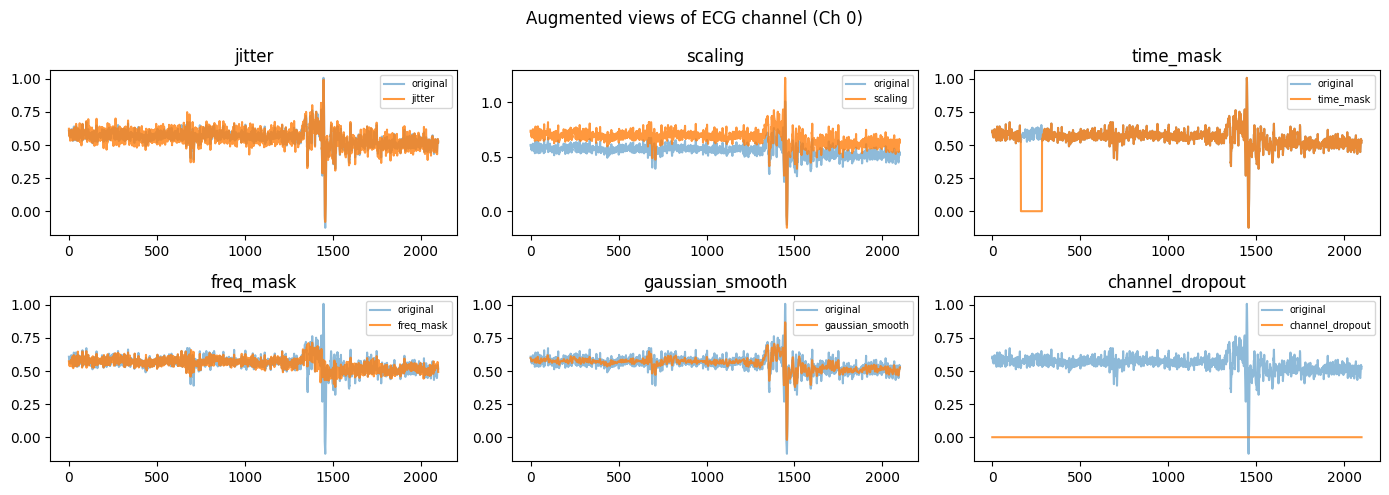

In [8]:
# ── 6 augmentation functions ─────────────────────────────────────────────────

def jitter(x, sigma=0.03):
    """Additive Gaussian noise."""
    return (x + np.random.normal(0, sigma, x.shape)).astype(np.float32)


def scaling(x, sigma=0.10):
    """Random per-channel amplitude scaling."""
    f = np.random.normal(1.0, sigma, (1, x.shape[1])).astype(np.float32)
    return (x * f).astype(np.float32)


def time_mask(x, max_frac=0.12):
    """Zero a random contiguous temporal segment."""
    y = x.copy(); T = y.shape[0]
    w = max(1, int(T * np.random.uniform(0.03, max_frac)))
    s = np.random.randint(0, max(1, T - w + 1))
    y[s:s+w] = 0.0
    return y


def freq_mask(x, max_frac=0.20):
    """Zero a random frequency band in every channel (FFT domain)."""
    y = x.copy(); T = y.shape[0]
    for ch in range(y.shape[1]):
        Xf = np.fft.rfft(y[:, ch])
        nf = len(Xf)
        w  = max(1, int(nf * np.random.uniform(0.05, max_frac)))
        s  = np.random.randint(0, max(1, nf - w + 1))
        Xf[s:s+w] = 0.0
        y[:, ch]  = np.fft.irfft(Xf, n=T)
    return y.astype(np.float32)


def gaussian_smooth(x, sigma_range=(1.0, 5.0)):
    """Gaussian low-pass filter per channel — simulates lower effective FS."""
    sigma = np.random.uniform(*sigma_range)
    y = np.stack([gaussian_filter1d(x[:, ch], sigma=sigma)
                  for ch in range(x.shape[1])], axis=1)
    return y.astype(np.float32)


def channel_dropout(x, p=0.25):
    """Zero entire channels independently with probability p."""
    y = x.copy()
    mask = (np.random.rand(x.shape[1]) > p).astype(np.float32)
    return (y * mask[None, :]).astype(np.float32)


# ── Composed augmentation (2 draws without replacement) ──────────────────────
AUG_POOL = [jitter, scaling, time_mask, freq_mask, gaussian_smooth, channel_dropout]


def compose_augment(x, n=2):
    """Apply n randomly sampled augmentations in sequence."""
    chosen = random.sample(AUG_POOL, n)
    y = x.copy()
    for f in chosen:
        y = f(y)
    return y


# Quick visual sanity-check
sample = X_train[0]
fig, axes = plt.subplots(2, 3, figsize=(14, 5))
names = ["jitter", "scaling", "time_mask", "freq_mask", "gaussian_smooth", "channel_dropout"]
funcs = [jitter,   scaling,   time_mask,   freq_mask,   gaussian_smooth,   channel_dropout]
for ax, name, fn in zip(axes.flat, names, funcs):
    ax.plot(sample[:, 0], alpha=0.5, label="original")
    ax.plot(fn(sample)[:, 0], alpha=0.8, label=name)
    ax.set_title(name); ax.legend(fontsize=7)
plt.suptitle("Augmented views of ECG channel (Ch 0)")
plt.tight_layout(); plt.show()

## BYOL Model (4-layer residual encoder, 256-dim)

In [9]:
class ResBlock1D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm1d(ch), nn.ReLU(),
            nn.Conv1d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm1d(ch))
        self.act = nn.ReLU()
    def forward(self, x): return self.act(x + self.net(x))


class Encoder1D(nn.Module):
    def __init__(self, in_ch=8, emb_dim=256):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv1d(in_ch,64,7,padding=3,bias=False),
                                    nn.BatchNorm1d(64),nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv1d(64,128,3,padding=1,bias=False),
                                    nn.BatchNorm1d(128),nn.ReLU(),ResBlock1D(128))
        self.layer2 = nn.Sequential(nn.Conv1d(128,256,3,padding=1,bias=False),
                                    nn.BatchNorm1d(256),nn.ReLU(),ResBlock1D(256))
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.fc     = nn.Linear(256, emb_dim)
    def forward(self, x):
        x = x.transpose(1,2)
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x)
        return F.normalize(self.fc(self.pool(x).squeeze(-1)), dim=1)


class MLP(nn.Module):
    def __init__(self, in_d, hid_d, out_d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_d,hid_d,bias=False),
                                  nn.BatchNorm1d(hid_d),nn.ReLU(),
                                  nn.Linear(hid_d,out_d))
    def forward(self, x): return F.normalize(self.net(x), dim=1)


class BYOL(nn.Module):
    def __init__(self, in_ch=8, emb_dim=256, proj_dim=256,
                 pred_dim=128, ema_decay=EMA_START):
        super().__init__()
        self.ema_decay   = ema_decay
        self.online_enc  = Encoder1D(in_ch, emb_dim)
        self.online_proj = MLP(emb_dim, proj_dim*2, proj_dim)
        self.predictor   = MLP(proj_dim, pred_dim,  proj_dim)
        self.target_enc  = copy.deepcopy(self.online_enc)
        self.target_proj = copy.deepcopy(self.online_proj)
        for p in self.target_enc.parameters():  p.requires_grad_(False)
        for p in self.target_proj.parameters(): p.requires_grad_(False)

    @torch.no_grad()
    def update_target(self):
        tau = self.ema_decay
        for po, pt in zip(self.online_enc.parameters(), self.target_enc.parameters()):
            pt.data.mul_(tau).add_((1-tau)*po.data)
        for po, pt in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            pt.data.mul_(tau).add_((1-tau)*po.data)

    def forward(self, x1, x2):
        h1 = self.online_enc(x1);  z1 = self.online_proj(h1); p1 = self.predictor(z1)
        h2 = self.online_enc(x2);  z2 = self.online_proj(h2); p2 = self.predictor(z2)
        with torch.no_grad():
            tz1 = self.target_proj(self.target_enc(x1))
            tz2 = self.target_proj(self.target_enc(x2))
        return h1, p1, p2, tz1, tz2


def byol_loss(p, z):
    return (2 - 2*F.cosine_similarity(p, z.detach(), dim=-1)).mean()


class LinearClassifier(nn.Module):
    def __init__(self, encoder, emb_dim=256, num_classes=3, freeze=True):
        super().__init__()
        self.encoder = encoder
        if freeze:
            for p in self.encoder.parameters(): p.requires_grad_(False)
        self.cls = nn.Linear(emb_dim, num_classes)
    def forward(self, x): return self.cls(self.encoder(x))


class SupervisedModel(nn.Module):
    def __init__(self, in_ch=8, emb_dim=256, num_classes=3):
        super().__init__()
        self.encoder = Encoder1D(in_ch, emb_dim)
        self.cls     = nn.Linear(emb_dim, num_classes)
    def forward(self, x): return self.cls(self.encoder(x))

print("Models defined.")

Models defined.


In [10]:
def evaluate(model, loader):
    model.eval(); ys, preds = [], []
    with torch.no_grad():
        for x, yb in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(yb.tolist())
    acc = accuracy_score(ys, preds)
    f1  = f1_score(ys, preds, average="macro")
    cm  = confusion_matrix(ys, preds)
    rep = classification_report(ys, preds,
            target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)])
    return acc, f1, cm, rep


def plot_cm(cm, title=""):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)],
                yticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)])
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()


def make_adamw(params, lr):
    return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)


def warmup_cosine(opt, total_ep):
    wu = min(WARMUP_EPOCHS, max(1, total_ep-1))
    def lr_fn(ep):
        if ep < wu: return (ep+1)/wu
        p = (ep-wu+1)/max(1, total_ep-wu)
        return MIN_LR_FACTOR + (1-MIN_LR_FACTOR)*0.5*(1+math.cos(math.pi*p))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)


class LabeledDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

## Temporal Neighbourhood Dataset

Positive pair: **(window_i, window_j)** where *j* is within ±`k` positions
of *i* in the same subject's time sequence. Nearby windows share the same
stress condition (conditions last several minutes). Both views are then
**composed** with 2 augmentations drawn independently.

In [11]:
class TemporalNeighborDS(Dataset):
    def __init__(self, X, groups, k=TEMPORAL_K):
        self.X  = X.astype(np.float32)
        self.k  = k
        self.neighbors = [None]*len(X)
        for sub in np.unique(groups):
            idx = np.where(groups == sub)[0]
            for pos, gi in enumerate(idx):
                lo = max(0, pos-k); hi = min(len(idx)-1, pos+k)
                cands = idx[lo:hi+1]
                self.neighbors[gi] = cands[cands != gi]

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        xi  = self.X[i]
        nbr = self.neighbors[i]
        j   = int(np.random.choice(nbr)) if len(nbr) > 0 else i
        xj  = self.X[j]
        # Independent 2-augmentation composition for each view
        return torch.tensor(compose_augment(xi)), torch.tensor(compose_augment(xj))

#### Setup with Transformer

In [17]:
# ============================================================
# QUICK TEST: VICReg + Strong CNN-Transformer Encoder
# Replaces BYOL / previous SSL comparison cell
# ============================================================

# Faster augmentations: remove slow FFT freq_mask
AUG_POOL = [jitter, scaling, time_mask, gaussian_smooth, channel_dropout]

SSL_TRY_EPOCHS = 25
STRONG_CKPT = os.path.join(OUTPUT_DIR, "vicreg_transformer_strong_best.pt")


class StrongCNNTransformerEncoder1D(nn.Module):
    def __init__(self, in_ch=8, emb_dim=256, d_model=192,
                 nhead=6, num_layers=3, dropout=0.15):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, 64, 9, stride=2, padding=4, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Conv1d(64, 128, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Conv1d(128, d_model, 5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(d_model),
            nn.GELU(),

            ResBlock1D(d_model)
        )

        self.pos_embed = nn.Parameter(torch.zeros(1, 400, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=num_layers
        )

        self.attn_pool = nn.Linear(d_model, 1)

        self.fc = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, emb_dim)
        )

    def forward(self, x):
        x = x.transpose(1, 2)      # [B, C, T]
        x = self.conv(x)           # [B, d_model, T']
        x = x.transpose(1, 2)      # [B, T', d_model]

        T = x.size(1)
        x = x + self.pos_embed[:, :T, :]

        x = self.transformer(x)

        w = self.attn_pool(x)
        w = torch.softmax(w, dim=1)
        x = (x * w).sum(dim=1)

        x = self.fc(x)
        return F.normalize(x, dim=1)


class StrongVICReg(nn.Module):
    def __init__(self, in_ch=8, emb_dim=256, proj_dim=256):
        super().__init__()

        self.encoder = StrongCNNTransformerEncoder1D(
            in_ch=in_ch,
            emb_dim=emb_dim,
            d_model=192,
            nhead=6,
            num_layers=3,
            dropout=0.15
        )

        self.projector = nn.Sequential(
            nn.Linear(emb_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def off_diagonal(x):
    n, m = x.shape
    assert n == m
    return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_loss(z1, z2, sim_w=25.0, var_w=25.0, cov_w=1.0, eps=1e-4):
    sim_loss = F.mse_loss(z1, z2)

    std_z1 = torch.sqrt(z1.var(dim=0) + eps)
    std_z2 = torch.sqrt(z2.var(dim=0) + eps)

    var_loss = torch.mean(F.relu(1 - std_z1))
    var_loss += torch.mean(F.relu(1 - std_z2))

    z1 = z1 - z1.mean(dim=0)
    z2 = z2 - z2.mean(dim=0)

    N, D = z1.shape
    cov_z1 = (z1.T @ z1) / max(1, N - 1)
    cov_z2 = (z2.T @ z2) / max(1, N - 1)

    cov_loss = off_diagonal(cov_z1).pow(2).sum() / D
    cov_loss += off_diagonal(cov_z2).pow(2).sum() / D

    return sim_w * sim_loss + var_w * var_loss + cov_w * cov_loss


# -----------------------------
# Dataloaders
# -----------------------------
ssl_ds = TemporalNeighborDS(X_all_norm, groups_all, k=TEMPORAL_K)
ssl_dl = DataLoader(
    ssl_ds,
    batch_size=SSL_BATCH,
    shuffle=True,
    drop_last=True,
    num_workers=0
)

val_ds = TemporalNeighborDS(X_val, g_val, k=TEMPORAL_K)
val_dl = DataLoader(
    val_ds,
    batch_size=SSL_BATCH,
    shuffle=False,
    drop_last=False,
    num_workers=0
)


# -----------------------------
# Train strong transformer VICReg
# -----------------------------
model = StrongVICReg(
    in_ch=N_CH,
    emb_dim=EMB_DIM,
    proj_dim=PROJ_DIM
).to(device)

opt = make_adamw(model.parameters(), lr=LR_SSL)
sched = warmup_cosine(opt, SSL_TRY_EPOCHS)

history = {"train_loss": [], "val_loss": [], "lr": []}
best_val = float("inf")

print("\nTraining VICReg + Strong CNN-Transformer")
print("Checkpoint:", STRONG_CKPT)

for epoch in range(SSL_TRY_EPOCHS):
    model.train()
    tr_loss = 0.0

    for x1, x2 in tqdm(
        ssl_dl,
        desc=f"StrongVICReg {epoch+1}/{SSL_TRY_EPOCHS}",
        leave=False
    ):
        x1 = x1.to(device)
        x2 = x2.to(device)

        _, z1 = model(x1)
        _, z2 = model(x2)

        loss = vicreg_loss(z1, z2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        tr_loss += loss.item()

    model.eval()
    va_loss = 0.0

    with torch.no_grad():
        for x1, x2 in val_dl:
            x1 = x1.to(device)
            x2 = x2.to(device)

            _, z1 = model(x1)
            _, z2 = model(x2)

            va_loss += vicreg_loss(z1, z2).item()

    tr_loss /= max(1, len(ssl_dl))
    va_loss /= max(1, len(val_dl))

    cur_lr = sched.get_last_lr()[0]
    sched.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["lr"].append(cur_lr)

    print(
        f"[StrongVICReg] ep {epoch+1:03d} | "
        f"train={tr_loss:.4f} | val={va_loss:.4f} | lr={cur_lr:.2e}"
    )

    if va_loss < best_val:
        best_val = va_loss
        torch.save(model.state_dict(), STRONG_CKPT)

print(f"\nBest Strong VICReg val loss: {best_val:.4f}")


# -----------------------------
# Load best pretrained encoder
# -----------------------------
best_ssl_model = StrongVICReg(
    in_ch=N_CH,
    emb_dim=EMB_DIM,
    proj_dim=PROJ_DIM
).to(device)

best_ssl_model.load_state_dict(
    torch.load(STRONG_CKPT, map_location=device)
)

pretrained_encoder = best_ssl_model.encoder

print("\npretrained_encoder is ready for LinearClassifier.")


Training VICReg + Strong CNN-Transformer
Checkpoint: /content/wesad_byol_outputs/vicreg_transformer_strong_best.pt


/tmp/ipykernel_4464/2186561569.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


StrongVICReg 1/25:   0%|          | 0/33 [00:00<?, ?it/s]

[StrongVICReg] ep 001 | train=33.5375 | val=42.1428 | lr=3.00e-05


StrongVICReg 2/25:   0%|          | 0/33 [00:00<?, ?it/s]

...

[StrongVICReg] ep 023 | train=22.8351 | val=60.9296 | lr=1.58e-05


StrongVICReg 24/25:   0%|          | 0/33 [00:00<?, ?it/s]

[StrongVICReg] ep 024 | train=22.9178 | val=80.6861 | lr=6.25e-06


StrongVICReg 25/25:   0%|          | 0/33 [00:00<?, ?it/s]

[StrongVICReg] ep 025 | train=23.1011 | val=64.5888 | lr=3.00e-06

Best Strong VICReg val loss: 42.1428

pretrained_encoder is ready for LinearClassifier.


In [18]:
linear_model = LinearClassifier(
    pretrained_encoder,
    emb_dim=EMB_DIM,
    num_classes=NUM_CLASSES,
    freeze=True
).to(device)

In [19]:
# ==================================================
# Linear Evaluation for Strong VICReg Transformer
# ==================================================

train_ds = LabeledDS(X_train, y_train)
val_ds   = LabeledDS(X_val, y_val)
test_ds  = LabeledDS(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=SUP_BATCH, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=SUP_BATCH, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=SUP_BATCH, shuffle=False)

linear_model = LinearClassifier(
    pretrained_encoder,
    emb_dim=EMB_DIM,
    num_classes=NUM_CLASSES,
    freeze=True
).to(device)

opt = make_adamw(linear_model.parameters(), lr=LR_LINEAR)
sched = warmup_cosine(opt, LINEAR_EPOCHS)
crit = nn.CrossEntropyLoss()

best_f1 = -1
best_linear_ckpt = os.path.join(
    OUTPUT_DIR,
    "best_linear_strong_vicreg_transformer.pt"
)

for epoch in range(LINEAR_EPOCHS):
    linear_model.train()

    for x, y in train_dl:
        x = x.to(device)
        y = y.to(device)

        out = linear_model(x)
        loss = crit(out, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

    sched.step()

    val_acc, val_f1, _, _ = evaluate(linear_model, val_dl)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(linear_model.state_dict(), best_linear_ckpt)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Val Acc={val_acc:.4f} | Val Macro-F1={val_f1:.4f}"
    )

print("Best Val Macro-F1:", best_f1)

Epoch 01 | Val Acc=0.5442 | Val Macro-F1=0.4527
Epoch 02 | Val Acc=0.4876 | Val Macro-F1=0.4109


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 03 | Val Acc=0.3781 | Val Macro-F1=0.2759


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 04 | Val Acc=0.3357 | Val Macro-F1=0.2447


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 28 | Val Acc=0.2933 | Val Macro-F1=0.2117


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 29 | Val Acc=0.2827 | Val Macro-F1=0.2034
Epoch 30 | Val Acc=0.2862 | Val Macro-F1=0.2057
Best Val Macro-F1: 0.45268842408615745


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TEST ACC: 0.24768518518518517
TEST MACRO-F1: 0.20909113120860415
              precision    recall  f1-score   support

    baseline       0.38      0.34      0.36       231
      stress       0.05      0.03      0.04       130
   amusement       0.17      0.35      0.23        71

    accuracy                           0.25       432
   macro avg       0.20      0.24      0.21       432
weighted avg       0.25      0.25      0.24       432



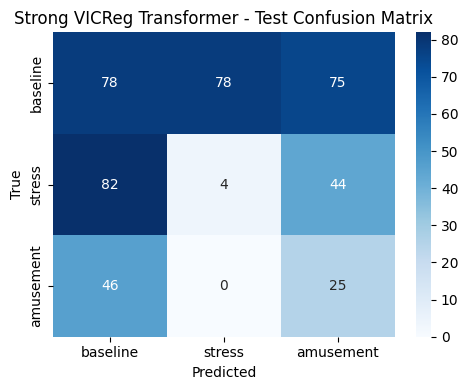

In [20]:
# ==================================================
# Final Test Evaluation
# ==================================================

linear_model.load_state_dict(
    torch.load(best_linear_ckpt, map_location=device)
)

test_acc, test_f1, test_cm, test_rep = evaluate(linear_model, test_dl)

print("TEST ACC:", test_acc)
print("TEST MACRO-F1:", test_f1)
print(test_rep)

plot_cm(test_cm, "Strong VICReg Transformer - Test Confusion Matrix")

Device: cuda
Found 15 subject files.
  S10: 148 windows  Counter({np.int64(0): 78, np.int64(1): 47, np.int64(2): 23})
  S11: 144 windows  Counter({np.int64(0): 77, np.int64(1): 44, np.int64(2): 23})
  S13: 143 windows  Counter({np.int64(0): 77, np.int64(1): 42, np.int64(2): 24})
  S14: 144 windows  Counter({np.int64(0): 77, np.int64(1): 44, np.int64(2): 23})
  S15: 143 windows  Counter({np.int64(0): 76, np.int64(1): 44, np.int64(2): 23})
  S16: 143 windows  Counter({np.int64(0): 77, np.int64(1): 43, np.int64(2): 23})
  S17: 149 windows  Counter({np.int64(0): 78, np.int64(1): 47, np.int64(2): 24})
  S2: 135 windows  Counter({np.int64(0): 74, np.int64(1): 39, np.int64(2): 22})
  S3: 138 windows  Counter({np.int64(0): 74, np.int64(1): 41, np.int64(2): 23})
  S4: 141 windows  Counter({np.int64(0): 76, np.int64(1): 41, np.int64(2): 24})
  S5: 144 windows  Counter({np.int64(0): 78, np.int64(1): 42, np.int64(2): 24})
  S6: 143 windows  Counter({np.int64(0): 77, np.int64(1): 42, np.int64(2): 2

SSL 001/60:   0%|          | 0/7 [00:00<?, ?it/s]

  ep 001 | train=35.8820 | val=49.4704 | lr=6.00e-05 ★


SSL 002/60:   0%|          | 0/7 [00:00<?, ?it/s]

  ep 002 | train=33.3916 | val=48.3009 | lr=1.20e-04 ★


...

  ep 058 | train=14.5485 | val=87.5943 | lr=3.97e-06


SSL 059/60:   0%|          | 0/7 [00:00<?, ?it/s]

  ep 059 | train=15.0553 | val=87.1363 | lr=3.24e-06


SSL 060/60:   0%|          | 0/7 [00:00<?, ?it/s]

  ep 060 | train=14.9869 | val=85.8483 | lr=3.00e-06

Best SSL val loss: 34.8687


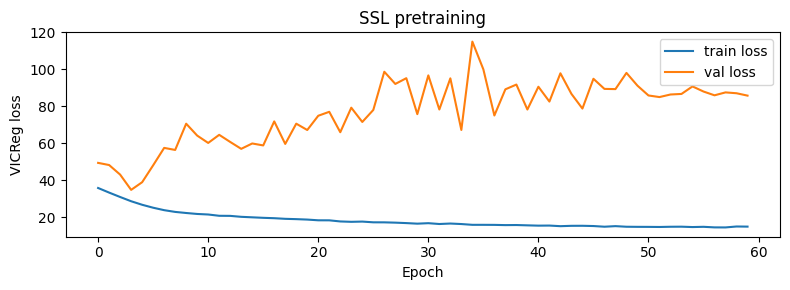

pretrained_encoder ready.

Embedding quality check (k=5 kNN on val set) …
  kNN val accuracy: 0.761  (random baseline ≈ 0.33)
  ✓ Embeddings carry class signal — proceed to linear probe.

Linear probe — 50 epochs


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  ep 01 | val_acc=0.7319 | val_f1=0.5242 ★
  ep 02 | val_acc=0.8043 | val_f1=0.7567 ★
  ep 03 | val_acc=0.8478 | val_f1=0.8377 ★
  ep 04 | val_acc=0.8406 | val_f1=0.8299
  ep 05 | val_acc=0.8406 | val_f1=0.8296
  ep 06 | val_acc=0.8116 | val_f1=0.7974
  ep 07 | val_acc=0.8188 | val_f1=0.8066
  ep 08 | val_acc=0.8043 | val_f1=0.7891
  ep 09 | val_acc=0.7899 | val_f1=0.7716
  ep 10 | val_acc=0.7971 | val_f1=0.7803
  ep 11 | val_acc=0.7899 | val_f1=0.7716
  ep 12 | val_acc=0.7899 | val_f1=0.7716
  ep 13 | val_acc=0.7899 | val_f1=0.7716
  ep 14 | val_acc=0.7899 | val_f1=0.7716
  ep 15 | val_acc=0.7899 | val_f1=0.7716
  ep 16 | val_acc=0.7899 | val_f1=0.7716
  ep 17 | val_acc=0.8043 | val_f1=0.7891
  ep 18 | val_acc=0.7899 | val_f1=0.7716
  ep 19 | val_acc=0.7899 | val_f1=0.7716
  ep 20 | val_acc=0.7899 | val_f1=0.7716
  ep 21 | val_acc=0.7899 | val_f1=0.7716
  ep 22 | val_acc=0.7899 | val_f1=0.7716
  ep 23 | val_acc=0.7899 | val_f1=0.7716
  ep 24 | val_acc=0.7899 | val_f1=0.7716
  ep 25 | 

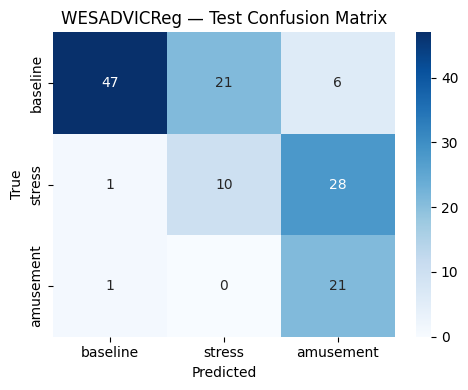

In [21]:
# ============================================================
# WESAD SSL — FULL PATCH
# Drop-in replacement for the broken VICReg + StrongTransformer cell
#
# Fixes applied vs previous code:
#   1. Per-subject normalisation (done inside load_subject_pkl)
#   2. Fixed subject splits — no test leakage into SSL pool
#   3. Label-aware TemporalNeighborDS — no cross-condition pairs
#   4. Safe augmentations — channel_dropout & freq_mask removed
#   5. Compact WESADEncoder — CNN only, ~400k params, fits 15 subjects
#   6. Batch size 256 minimum for VICReg cov term stability
#   7. Gradient clipping kept, GELU throughout
# ============================================================

import os, glob, pickle, random, math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ─────────────────────────────────────────────────────────────
# CONFIG  (keep in sync with your notebook globals)
# ─────────────────────────────────────────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/FIU/class_elements/CAP6619/Project/WESAD"
OUTPUT_DIR = "/content/wesad_byol_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

ORIG_FS    = 700
DOWNSAMPLE = 10
FS         = ORIG_FS // DOWNSAMPLE          # 70 Hz

WINDOW_SEC = 30
STEP_SEC   = 15
WIN        = WINDOW_SEC * FS               # 2100 samples
STEP       = STEP_SEC   * FS              # 1050 samples
PURITY     = 0.90

# WESAD raw labels: 0=transient 1=baseline 2=stress 3=amusement 4=meditation
LABEL_MAP   = {1: 0, 2: 1, 3: 2}
ID2LABEL    = {0: "baseline", 1: "stress", 2: "amusement"}
NUM_CLASSES = 3

# Channel layout after load_subject_pkl concatenation:
#   [ACC_x(0), ACC_y(1), ACC_z(2), ECG(3), EDA(4), EMG(5), RESP(6), TEMP(7)]
STRESS_CHANNELS = [3, 4, 6, 7]   # ECG, EDA, RESP, TEMP — never drop
MOTION_CHANNELS = [0, 1, 2]      # ACC — safe to augment aggressively

EMB_DIM   = 128    # reduced from 256 — right-sized for 15 subjects
PROJ_DIM  = 128
SSL_BATCH = 256    # MUST be ≥256 for VICReg covariance term
SUP_BATCH = 128
SSL_EPOCHS    = 60
LINEAR_EPOCHS = 50
LR_SSL    = 3e-4
LR_LINEAR = 1e-2
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 5
MIN_LR_FACTOR = 0.01
TEMPORAL_K    = 6   # tighter window — reduces boundary leakage risk

# Fixed subject splits — deterministic, no random leakage
TEST_SUBJ = "S2"
VAL_SUBJ  = "S3"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ─────────────────────────────────────────────────────────────
# 1. DATA LOADING  (per-subject normalisation baked in)
# ─────────────────────────────────────────────────────────────

def get_key(d, keys):
    for k in keys:
        if k in d: return d[k]
    raise KeyError(f"None of {keys} found")


def load_subject_pkl(pkl_path):
    """
    Load one WESAD subject pickle.
    Returns x [N,8] float32 normalised per-channel, y [N] raw labels.
    Channel order: ACC_x, ACC_y, ACC_z, ECG, EDA, EMG, RESP, TEMP
    """
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest = data["signal"]["chest"]
    y     = np.asarray(data["label"]).reshape(-1)

    acc  = np.asarray(get_key(chest, ["ACC"])).astype(np.float32)          # [N,3]
    ecg  = np.asarray(get_key(chest, ["ECG"])).reshape(-1,1).astype(np.float32)
    eda  = np.asarray(get_key(chest, ["EDA"])).reshape(-1,1).astype(np.float32)
    emg  = np.asarray(get_key(chest, ["EMG"])).reshape(-1,1).astype(np.float32)
    resp = np.asarray(get_key(chest, ["Resp","RESP"])).reshape(-1,1).astype(np.float32)
    temp = np.asarray(get_key(chest, ["Temp","TEMP"])).reshape(-1,1).astype(np.float32)

    x = np.concatenate([acc, ecg, eda, emg, resp, temp], axis=1)  # [N,8]

    # ── Per-subject, per-channel z-score ──────────────────────
    # Use only baseline+stress+amusement samples for stats
    # to avoid transient/meditation segments skewing the mean
    valid = np.isin(y, [1, 2, 3])
    mu  = x[valid].mean(axis=0, keepdims=True)
    std = x[valid].std(axis=0,  keepdims=True) + 1e-6
    x   = (x - mu) / std

    return x, y


def make_windows(x, y, win, step, label_map, purity=0.90):
    Xw, yw = [], []
    for s in range(0, len(y) - win + 1, step):
        e   = s + win
        seg = y[s:e]
        vals, cnts = np.unique(seg, return_counts=True)
        maj = vals[np.argmax(cnts)]
        if maj not in label_map or cnts.max()/len(seg) < purity:
            continue
        Xw.append(x[s:e])
        yw.append(label_map[maj])
    if not Xw:
        return np.empty((0, win, x.shape[1]), np.float32), np.empty((0,), np.int64)
    return np.stack(Xw).astype(np.float32), np.array(yw, np.int64)


# ── Load all subjects ──────────────────────────────────────────
pkl_files = sorted(glob.glob(os.path.join(DATA_ROOT, "S*", "S*.pkl")))
print(f"Found {len(pkl_files)} subject files.")

X_all_list, y_all_list, groups_all_list = [], [], []

for pkl_path in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_path))
    x, y = load_subject_pkl(pkl_path)
    x, y = x[::DOWNSAMPLE], y[::DOWNSAMPLE]
    Xw, yw = make_windows(x, y, WIN, STEP, LABEL_MAP, PURITY)
    if not len(Xw):
        print(f"  {sid}: skipped (no valid windows)")
        continue
    X_all_list.append(Xw)
    y_all_list.append(yw)
    groups_all_list.extend([sid] * len(yw))
    print(f"  {sid}: {len(yw)} windows  {Counter(yw)}")

X_all      = np.concatenate(X_all_list)
y_all      = np.concatenate(y_all_list)
groups_all = np.array(groups_all_list)
N_CH       = X_all.shape[2]   # 8
print(f"\nAll subjects: {X_all.shape}  classes: {Counter(y_all)}")


# ── Fixed deterministic splits ────────────────────────────────
test_mask  = groups_all == TEST_SUBJ
val_mask   = groups_all == VAL_SUBJ
train_mask = ~test_mask & ~val_mask

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]
g_train          = groups_all[train_mask]
g_val            = groups_all[val_mask]

# SSL pool = all subjects except test (val subjects included — they contribute
# to pretraining but are excluded from downstream label evaluation)
ssl_mask    = ~test_mask
X_ssl       = X_all[ssl_mask]
y_ssl       = y_all[ssl_mask]          # used only for pair-guard
groups_ssl  = groups_all[ssl_mask]

print(f"\nSplits:")
print(f"  Train : {X_train.shape}  {Counter(y_train)}")
print(f"  Val   : {X_val.shape}   {Counter(y_val)}")
print(f"  Test  : {X_test.shape}  {Counter(y_test)}")
print(f"  SSL   : {X_ssl.shape}")


# ─────────────────────────────────────────────────────────────
# 2. AUGMENTATIONS  (WESAD-safe)
# ─────────────────────────────────────────────────────────────

def aug_amplitude_jitter(x, sigma=0.05):
    """Per-channel multiplicative + additive jitter."""
    scale = 1.0 + sigma * np.random.randn(1, x.shape[1]).astype(np.float32)
    bias  = (sigma * 0.3) * np.random.randn(1, x.shape[1]).astype(np.float32)
    return (x * scale + bias).astype(np.float32)


def aug_gaussian_noise(x, sigma=0.02):
    return (x + sigma * np.random.randn(*x.shape)).astype(np.float32)


def aug_time_mask(x, max_frac=0.10):
    """Mask a short contiguous segment — ≤10% so stress signal survives."""
    y = x.copy(); T = y.shape[0]
    w = max(1, int(T * np.random.uniform(0.02, max_frac)))
    s = np.random.randint(0, max(1, T - w + 1))
    y[s:s+w] = 0.0
    return y


def aug_temporal_shift(x, max_frac=0.04):
    """Slight circular shift — simulates sensor sync offset."""
    T     = x.shape[0]
    shift = int(T * max_frac * (2 * np.random.rand() - 1))
    return np.roll(x, shift, axis=0).astype(np.float32)


def aug_channel_scale(x, sigma=0.10):
    """Independent per-channel gain — electrode impedance variation."""
    gains = np.clip(1.0 + sigma * np.random.randn(1, x.shape[1]), 0.5, 1.5).astype(np.float32)
    return (x * gains).astype(np.float32)


def aug_baseline_wander(x, amplitude=0.04, fs=70.0):
    """Low-freq sine on ECG+RESP only — realistic breathing artifact."""
    T    = x.shape[0]
    t    = np.linspace(0, T / fs, T, dtype=np.float32)
    freq = np.random.uniform(0.05, 0.4)
    wave = amplitude * np.sin(2 * np.pi * freq * t + np.random.uniform(0, 2*np.pi))
    y = x.copy()
    y[:, 3] += wave          # ECG
    y[:, 6] += wave * 0.5   # RESP
    return y.astype(np.float32)


def aug_acc_sign_flip(x, p=0.3):
    """Flip polarity of random ACC axes — wrist orientation ambiguity."""
    y = x.copy()
    for ch in MOTION_CHANNELS:
        if np.random.rand() < p:
            y[:, ch] = -y[:, ch]
    return y.astype(np.float32)


# Pool ordered weakest → strongest
AUG_POOL = [
    aug_gaussian_noise,
    aug_amplitude_jitter,
    aug_channel_scale,
    aug_baseline_wander,
    aug_temporal_shift,
    aug_time_mask,
    aug_acc_sign_flip,
]


def compose_augment(x, n=4):
    """Apply n randomly chosen augmentations from pool."""
    chosen = np.random.choice(len(AUG_POOL), size=n, replace=False)
    y = x.copy()
    for idx in chosen:
        y = AUG_POOL[idx](y)
    return y.astype(np.float32)


# ─────────────────────────────────────────────────────────────
# 3. DATASET  — label-aware pair sampling
# ─────────────────────────────────────────────────────────────

class WESADPairDS(Dataset):
    """
    Positive pairs are sampled from within the same (subject, condition)
    segment — guarantees no cross-label boundary pairing.
    """
    def __init__(self, X, labels, groups, k=TEMPORAL_K):
        self.X = X.astype(np.float32)

        from collections import defaultdict
        seg_map = defaultdict(list)
        for i in range(len(X)):
            # Skip transient windows that slipped through purity filter
            if labels[i] < 0:
                continue
            key = (groups[i], int(labels[i]))
            seg_map[key].append(i)

        # Sort so indices are temporally ordered within each segment
        for key in seg_map:
            seg_map[key].sort()

        self.valid_idx = []
        self.neighbors = {}

        for key, idxs in seg_map.items():
            idxs = np.array(idxs)
            for pos, gi in enumerate(idxs):
                lo    = max(0, pos - k)
                hi    = min(len(idxs) - 1, pos + k)
                cands = idxs[lo:hi+1]
                cands = cands[cands != gi]
                self.neighbors[gi] = cands if len(cands) > 0 else np.array([gi])
                self.valid_idx.append(gi)

        self.valid_idx = np.array(self.valid_idx)
        print(f"  WESADPairDS: {len(self.valid_idx)} valid anchor windows")

    def __len__(self):
        return len(self.valid_idx)

    def __getitem__(self, i):
        gi  = self.valid_idx[i]
        j   = int(np.random.choice(self.neighbors[gi]))
        x1  = compose_augment(self.X[gi])
        x2  = compose_augment(self.X[j])
        return torch.from_numpy(x1), torch.from_numpy(x2)


class LabeledDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


# ─────────────────────────────────────────────────────────────
# 4. ENCODER  — compact CNN, right-sized for WESAD
# ─────────────────────────────────────────────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, ch, kernel=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(ch, ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm1d(ch),
        )
        self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.net(x))


class WESADEncoder(nn.Module):
    """
    ~400k parameters.
    Three conv stages with strided downsampling + two ResBlocks,
    then learned attention pooling over the time dimension.
    No Transformer — WESAD does not have the scale to justify one.
    """
    def __init__(self, in_ch=8, emb_dim=128):
        super().__init__()
        self.stem = nn.Sequential(
            # Fast transients: ECG QRS, EDA peaks
            nn.Conv1d(in_ch, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32), nn.GELU(),
            # Mid-range dynamics
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(64), nn.GELU(),
            ResBlock1D(64),
            # Slow trends: TEMP drift, tonic EDA
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.GELU(),
            ResBlock1D(128),
        )
        # Attention pooling — focus on informative time steps
        self.attn = nn.Conv1d(128, 1, kernel_size=1)
        self.head  = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, emb_dim),
        )

    def forward(self, x):
        x = x.transpose(1, 2)                          # [B, C, T]
        f = self.stem(x)                                # [B, 128, T']
        w = torch.softmax(self.attn(f), dim=2)          # [B, 1, T']
        z = (f * w).sum(dim=2)                          # [B, 128]
        return F.normalize(self.head(z), dim=1)


# ─────────────────────────────────────────────────────────────
# 5. VICReg MODEL + LOSS
# ─────────────────────────────────────────────────────────────

class WESADVICReg(nn.Module):
    def __init__(self, in_ch=8, emb_dim=128, proj_dim=128):
        super().__init__()
        self.encoder   = WESADEncoder(in_ch=in_ch, emb_dim=emb_dim)
        self.projector = nn.Sequential(
            nn.Linear(emb_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim), nn.GELU(),
            nn.Linear(proj_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim), nn.GELU(),
            nn.Linear(proj_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def off_diagonal(x):
    n = x.shape[0]
    return x.flatten()[:-1].view(n-1, n+1)[:, 1:].flatten()


def vicreg_loss(z1, z2, sim_w=25.0, var_w=25.0, cov_w=1.0, eps=1e-4):
    sim_loss  = F.mse_loss(z1, z2)

    std1 = torch.sqrt(z1.var(dim=0) + eps)
    std2 = torch.sqrt(z2.var(dim=0) + eps)
    var_loss  = F.relu(1 - std1).mean() + F.relu(1 - std2).mean()

    z1c = z1 - z1.mean(dim=0);  z2c = z2 - z2.mean(dim=0)
    N, D = z1c.shape
    cov1 = (z1c.T @ z1c) / max(1, N-1)
    cov2 = (z2c.T @ z2c) / max(1, N-1)
    cov_loss = off_diagonal(cov1).pow(2).sum()/D + off_diagonal(cov2).pow(2).sum()/D

    return sim_w * sim_loss + var_w * var_loss + cov_w * cov_loss


# ─────────────────────────────────────────────────────────────
# 6. SCHEDULERS
# ─────────────────────────────────────────────────────────────

def make_adamw(params, lr, wd=WEIGHT_DECAY):
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)


def warmup_cosine(opt, total_ep, warmup=WARMUP_EPOCHS):
    wu = min(warmup, max(1, total_ep-1))
    def lr_fn(ep):
        if ep < wu: return (ep+1)/wu
        p = (ep-wu+1) / max(1, total_ep-wu)
        return MIN_LR_FACTOR + (1-MIN_LR_FACTOR)*0.5*(1+math.cos(math.pi*p))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)


# ─────────────────────────────────────────────────────────────
# 7. SSL PRETRAINING
# ─────────────────────────────────────────────────────────────

VICREG_CKPT = os.path.join(OUTPUT_DIR, "wesad_vicreg_best.pt")

print("\nBuilding SSL datasets …")
ssl_ds = WESADPairDS(X_ssl,   y_ssl,   groups_ssl, k=TEMPORAL_K)
vds    = WESADPairDS(X_val,   y_val,   g_val,      k=TEMPORAL_K)

ssl_dl = DataLoader(ssl_ds, batch_size=SSL_BATCH, shuffle=True,
                    drop_last=True,  num_workers=2, pin_memory=True)
vdl    = DataLoader(vds,    batch_size=SSL_BATCH, shuffle=False,
                    drop_last=False, num_workers=2, pin_memory=True)

print(f"SSL steps/epoch: {len(ssl_dl)}")

vicreg = WESADVICReg(in_ch=N_CH, emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
n_params = sum(p.numel() for p in vicreg.parameters() if p.requires_grad)
print(f"VICReg parameters: {n_params:,}")

opt_ssl   = make_adamw(vicreg.parameters(), lr=LR_SSL)
sched_ssl = warmup_cosine(opt_ssl, SSL_EPOCHS)

ssl_history = {"train": [], "val": [], "lr": []}
best_ssl_val = float("inf")

print(f"\nTraining VICReg — {SSL_EPOCHS} epochs, batch {SSL_BATCH}")
for epoch in range(SSL_EPOCHS):
    vicreg.train(); tr = 0.0
    for x1, x2 in tqdm(ssl_dl, desc=f"SSL {epoch+1:03d}/{SSL_EPOCHS}", leave=False):
        x1, x2 = x1.to(device), x2.to(device)
        _, z1 = vicreg(x1);  _, z2 = vicreg(x2)
        loss  = vicreg_loss(z1, z2)
        opt_ssl.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(vicreg.parameters(), 5.0)
        opt_ssl.step()
        tr += loss.item()

    vicreg.eval(); va = 0.0
    with torch.no_grad():
        for x1, x2 in vdl:
            x1, x2 = x1.to(device), x2.to(device)
            _, z1 = vicreg(x1);  _, z2 = vicreg(x2)
            va += vicreg_loss(z1, z2).item()

    tr /= max(1, len(ssl_dl));  va /= max(1, len(vdl))
    lr  = opt_ssl.param_groups[0]["lr"];  sched_ssl.step()

    ssl_history["train"].append(tr)
    ssl_history["val"].append(va)
    ssl_history["lr"].append(lr)

    tag = " ★" if va < best_ssl_val else ""
    print(f"  ep {epoch+1:03d} | train={tr:.4f} | val={va:.4f} | lr={lr:.2e}{tag}")
    if va < best_ssl_val:
        best_ssl_val = va
        torch.save(vicreg.state_dict(), VICREG_CKPT)

print(f"\nBest SSL val loss: {best_ssl_val:.4f}")

# Plot SSL curves
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ssl_history["train"], label="train loss")
ax.plot(ssl_history["val"],   label="val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("VICReg loss")
ax.set_title("SSL pretraining"); ax.legend(); plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# 8. LOAD BEST ENCODER
# ─────────────────────────────────────────────────────────────

best_vicreg = WESADVICReg(in_ch=N_CH, emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
best_vicreg.load_state_dict(torch.load(VICREG_CKPT, map_location=device))
pretrained_encoder = best_vicreg.encoder
pretrained_encoder.eval()
print("pretrained_encoder ready.")


# ─────────────────────────────────────────────────────────────
# 9. EMBEDDING QUALITY CHECK  (run before linear probe)
#    If kNN acc ≈ 33% the encoder learned nothing — debug before continuing
# ─────────────────────────────────────────────────────────────

@torch.no_grad()
def extract_embeddings(encoder, X, batch_size=512):
    encoder.eval()
    ds = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    embs = []
    for (xb,) in dl:
        embs.append(encoder(xb.to(device)).cpu())
    return torch.cat(embs).numpy()


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as acc_score

print("\nEmbedding quality check (k=5 kNN on val set) …")
emb_tr = extract_embeddings(pretrained_encoder, X_train)
emb_va = extract_embeddings(pretrained_encoder, X_val)

knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(emb_tr, y_train)
knn_acc = acc_score(y_val, knn.predict(emb_va))
print(f"  kNN val accuracy: {knn_acc:.3f}  (random baseline ≈ 0.33)")
if knn_acc < 0.40:
    print("  ⚠ Embeddings are near-random. Check pair sampling and augmentations.")
else:
    print("  ✓ Embeddings carry class signal — proceed to linear probe.")


# ─────────────────────────────────────────────────────────────
# 10. LINEAR PROBE
# ─────────────────────────────────────────────────────────────

class LinearClassifier(nn.Module):
    def __init__(self, encoder, emb_dim=128, num_classes=3, freeze=True):
        super().__init__()
        self.encoder = encoder
        if freeze:
            for p in self.encoder.parameters(): p.requires_grad_(False)
        self.cls = nn.Linear(emb_dim, num_classes)
    def forward(self, x): return self.cls(self.encoder(x))


def evaluate(model, loader):
    model.eval(); ys, preds = [], []
    with torch.no_grad():
        for x, yb in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(yb.tolist())
    acc = accuracy_score(ys, preds)
    f1  = f1_score(ys, preds, average="macro")
    cm  = confusion_matrix(ys, preds)
    rep = classification_report(ys, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)])
    return acc, f1, cm, rep


train_dl_sup = DataLoader(LabeledDS(X_train, y_train), batch_size=SUP_BATCH, shuffle=True)
val_dl_sup   = DataLoader(LabeledDS(X_val,   y_val),   batch_size=SUP_BATCH, shuffle=False)
test_dl_sup  = DataLoader(LabeledDS(X_test,  y_test),  batch_size=SUP_BATCH, shuffle=False)

linear_model = LinearClassifier(pretrained_encoder, emb_dim=EMB_DIM,
                                 num_classes=NUM_CLASSES, freeze=True).to(device)

opt_lin   = make_adamw(linear_model.parameters(), lr=LR_LINEAR)
sched_lin = warmup_cosine(opt_lin, LINEAR_EPOCHS)
crit      = nn.CrossEntropyLoss()

best_f1        = -1
LINEAR_CKPT    = os.path.join(OUTPUT_DIR, "wesad_linear_best.pt")
linear_history = {"val_acc": [], "val_f1": []}

print(f"\nLinear probe — {LINEAR_EPOCHS} epochs")
for epoch in range(LINEAR_EPOCHS):
    linear_model.train()
    for x, y in train_dl_sup:
        x, y = x.to(device), y.to(device)
        loss = crit(linear_model(x), y)
        opt_lin.zero_grad(); loss.backward(); opt_lin.step()
    sched_lin.step()

    val_acc, val_f1, _, _ = evaluate(linear_model, val_dl_sup)
    linear_history["val_acc"].append(val_acc)
    linear_history["val_f1"].append(val_f1)

    tag = " ★" if val_f1 > best_f1 else ""
    print(f"  ep {epoch+1:02d} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}{tag}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(linear_model.state_dict(), LINEAR_CKPT)

# Final test evaluation
linear_model.load_state_dict(torch.load(LINEAR_CKPT, map_location=device))
test_acc, test_f1, test_cm, test_rep = evaluate(linear_model, test_dl_sup)

print(f"\n{'='*50}")
print(f"TEST ACC:      {test_acc:.4f}")
print(f"TEST MACRO-F1: {test_f1:.4f}")
print(test_rep)

plt.figure(figsize=(5,4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)],
            yticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)])
plt.title("WESADVICReg — Test Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()